# 03 · Reaction conditions EDA

Deeper exploratory analysis of reaction times and yields: distributions, curated-vs-mined comparisons, and the relationship between reaction time and yield.

In [1]:
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

from ord_analysis.db import get_engine
from ord_analysis import queries

load_dotenv()
engine = get_engine()
sns.set_theme(style="whitegrid")

## Reaction times

`Time` values are stored with heterogeneous units (SECOND/MINUTE/HOUR/DAY); `queries.reaction_times` normalizes them to hours.

In [2]:
times = queries.reaction_times(engine)
print(times.shape)
times["hours"].describe()

(1052378, 4)


count    1.052378e+06
mean     9.320917e+00
std      1.806319e+01
min      0.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      1.600000e+01
max      2.160000e+03
Name: hours, dtype: float64

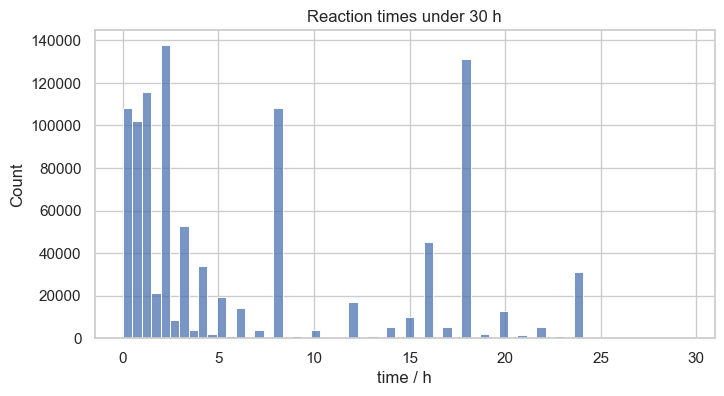

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(times.loc[times["hours"] < 30, "hours"], bins=60, ax=ax)
ax.set_title("Reaction times under 30 h")
ax.set_xlabel("time / h")
plt.show()

## Yields

In [4]:
yields = queries.yields(engine)
print(yields.shape)
yields["value"].describe()

(1601269, 9)


count    1.601269e+06
mean     5.638940e+13
std      7.128521e+16
min     -8.473668e+00
25%      3.710000e+01
50%      6.600000e+01
75%      8.620000e+01
max      9.020516e+19
Name: value, dtype: float64

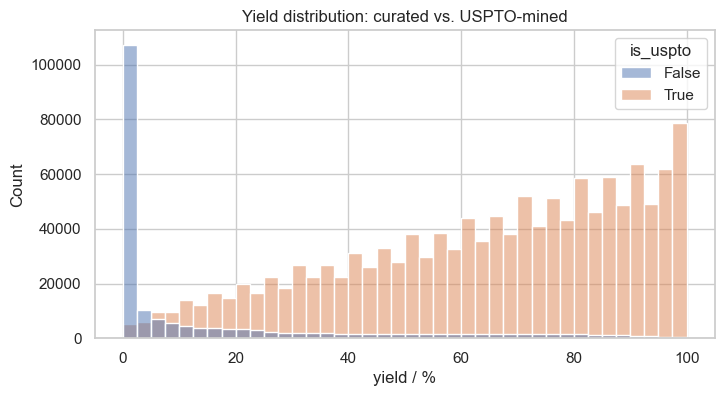

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = yields[(yields["value"] >= 0) & (yields["value"] <= 100)]
sns.histplot(data=plot_data, x="value", hue="is_uspto", bins=40, multiple="layer", alpha=0.5, ax=ax)
ax.set_title("Yield distribution: curated vs. USPTO-mined")
ax.set_xlabel("yield / %")
plt.show()

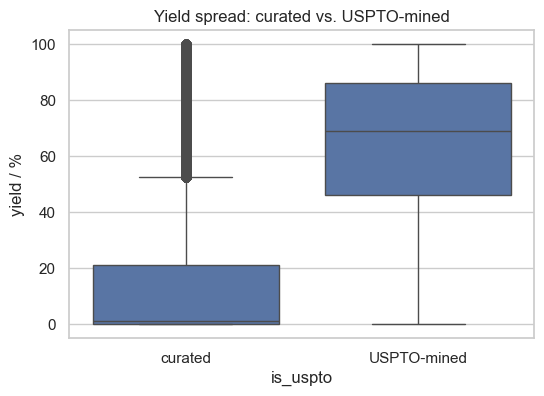

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=plot_data, x="is_uspto", y="value", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["curated", "USPTO-mined"])
ax.set_ylabel("yield / %")
ax.set_title("Yield spread: curated vs. USPTO-mined")
plt.show()

## Reaction time vs. yield

`queries.time_and_yield` pairs the reaction time and yield reported for the *same* `ReactionOutcome`, so we can look at whether they're related.

In [7]:
time_yield = queries.time_and_yield(engine)
print(time_yield.shape)
time_yield.head()

(1016459, 6)


,reaction_id,is_mined,reaction_time_value,reaction_time_units,yield_value,reaction_time_hours
0,ord-aa775880ee5b480896f2619381c4dc7e,True,4.0,DAY,173.699997,96.0
1,ord-77ecea47c92b4de49601a091efcd4b91,True,2.0,HOUR,93.900002,2.0
2,ord-39c43a50322a4e8ebd23910cb724fcc3,True,1.0,HOUR,69.300003,1.0
3,ord-b4685538e6b8446fb9eabb0b5495e015,True,30.0,MINUTE,83.599998,0.5
4,ord-227139b0204b412c8ef4f1e745340ffc,True,1.0,HOUR,90.000000,1.0


Pearson correlation (reaction time vs. yield, n=749662): -0.023


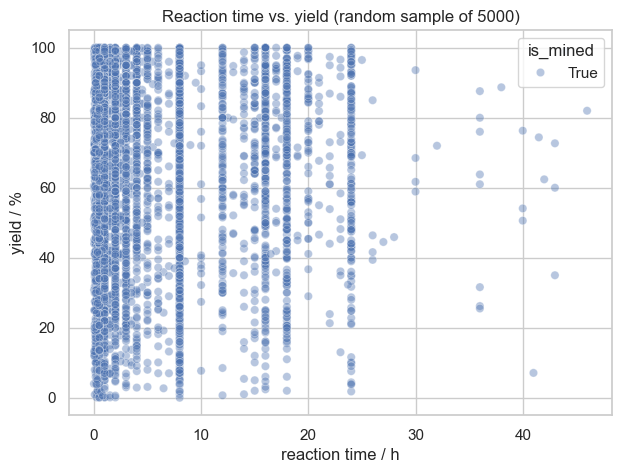

In [8]:
plot_data = time_yield[
    (time_yield["reaction_time_hours"] < 48)
    & (time_yield["yield_value"] >= 0)
    & (time_yield["yield_value"] <= 100)
].dropna(subset=["is_mined"])
corr = plot_data["reaction_time_hours"].corr(plot_data["yield_value"])
print(f"Pearson correlation (reaction time vs. yield, n={len(plot_data)}): {corr:.3f}")

sample = plot_data.sample(n=min(5000, len(plot_data)), random_state=0)
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=sample, x="reaction_time_hours", y="yield_value", hue="is_mined", alpha=0.4, ax=ax)
ax.set_xlabel("reaction time / h")
ax.set_ylabel("yield / %")
ax.set_title(f"Reaction time vs. yield (random sample of {len(sample)})")
plt.show()